In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
col_names = ['age', 'workclass', 'fnlwgt','education', 'education-num', 
             'marital-status', 'occupation', 'relationship', 'race', 'sex',
             'capital-gain','capital-loss', 'hours-per-week','native-country', 'income']
df = pd.read_csv('adult.data', header=None, names=col_names)

In [54]:
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

In [55]:
# 1. Check class imbalance
print(df.income.value_counts(normalize=True))

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [56]:
# 2. Feature DataFrame with dummies
feature_cols = ['age','capital-gain', 'capital-loss', 'hours-per-week', 'sex','race', 'education']
X = pd.get_dummies(df[feature_cols], drop_first=True)

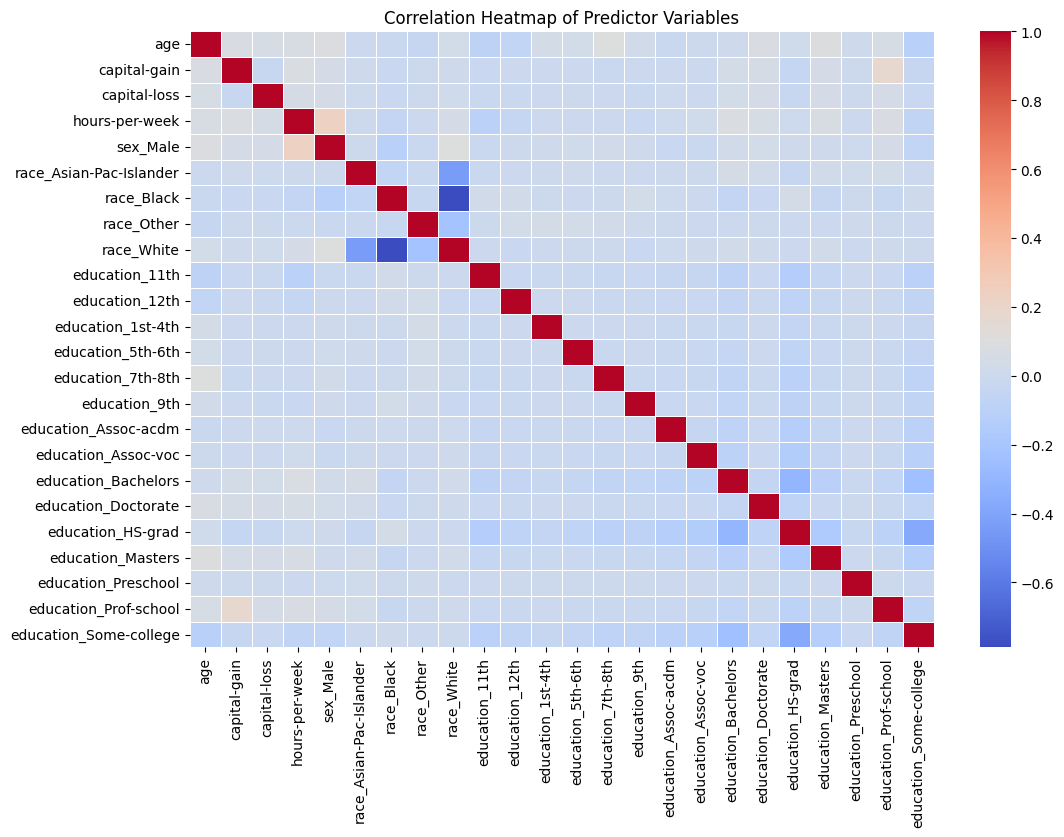

In [57]:

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of Predictor Variables")
plt.show()

In [58]:
# 3. Scale numeric features only
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['uint8','bool']).columns
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', 'passthrough', categorical_features)
])
X_scaled = preprocessor.fit_transform(X)
feature_names = list(numeric_features) + list(categorical_features)


In [59]:
# 4. Target variable
y = (df['income'] == '>50K').astype(int)
print(y.value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


In [60]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1)

In [61]:
# 6. Logistic Regression model
log_reg = LogisticRegression(C=0.05, penalty='l1', solver='liblinear')
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

In [62]:
# 7. Model parameters
print("Intercept:", log_reg.intercept_)
print("Coefficients:", log_reg.coef_)

Intercept: [-2.54554718]
Coefficients: [[ 0.52367783  2.22457657  0.26405106  0.42057915  1.03131138  0.
  -0.30323221  0.          0.12638693 -0.56033527  0.          0.
  -0.39953656 -0.90907647 -0.50434894  0.58306546  0.55835691  1.29365557
   1.79434258  0.          1.60372394  0.          1.82362105  0.39540372]]


In [63]:
# 8. Confusion matrix & accuracy
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[4769  257]
 [ 881  606]]
Accuracy: 0.8252725318593582


In [64]:
# 9. Coefficient DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient')
print(coef_df)


                   Feature  Coefficient
13       education_7th-8th    -0.909076
9           education_11th    -0.560335
14           education_9th    -0.504349
12       education_5th-6th    -0.399537
6               race_Black    -0.303232
8               race_White     0.126387
2             capital-loss     0.264051
23  education_Some-college     0.395404
3           hours-per-week     0.420579
0                      age     0.523678
16     education_Assoc-voc     0.558357
15    education_Assoc-acdm     0.583065
4                 sex_Male     1.031311
17     education_Bachelors     1.293656
20       education_Masters     1.603724
18     education_Doctorate     1.794343
22   education_Prof-school     1.823621
1             capital-gain     2.224577


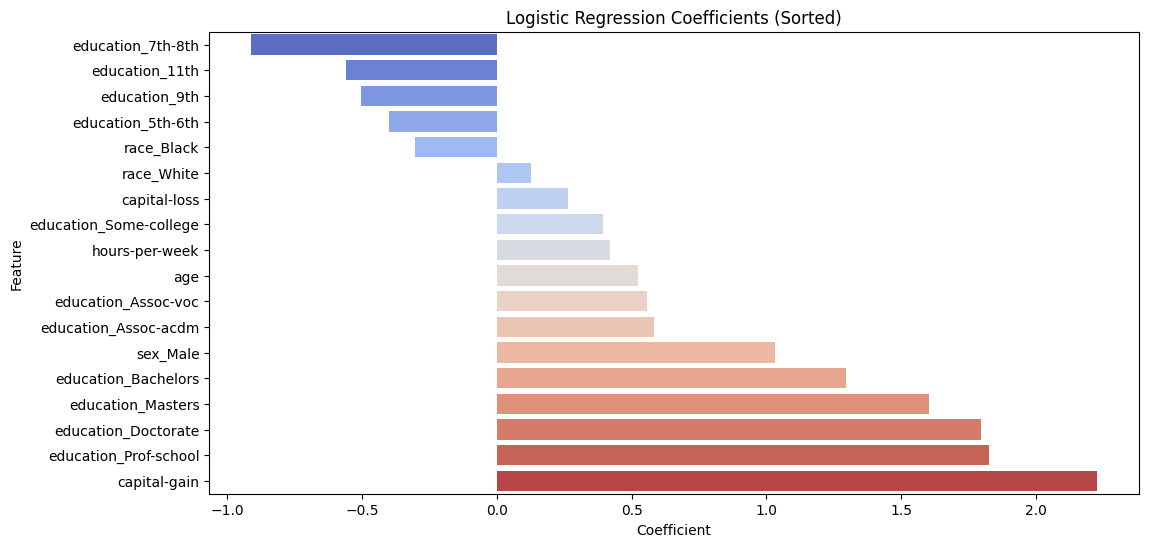

In [65]:
# Barplot of coefficients
plt.figure(figsize=(12,6))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df, palette="coolwarm", dodge=False, legend=False)
plt.title("Logistic Regression Coefficients (Sorted)")
plt.show()


In [66]:
# 10. ROC curve & AUC
y_pred_prob = log_reg.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_value = roc_auc_score(y_test, y_pred_prob)
print("AUC Value:", auc_value)

AUC Value: 0.8460234086047778


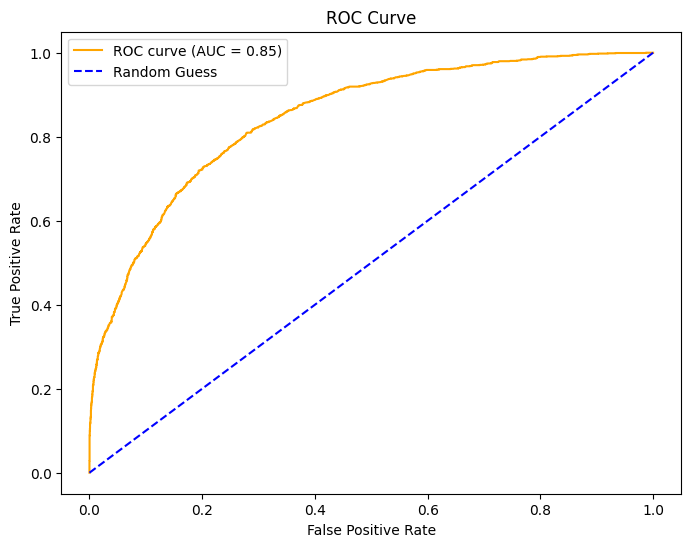

In [67]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='orange', label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0,1], [0,1], color='blue', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()